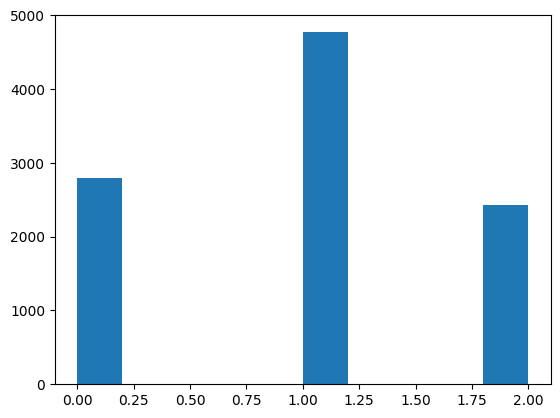

In [11]:
import numpy as np 
import matplotlib.pyplot as plt

P =[[0.4,0.2,0.4],
[0.2,0.7,0.1],
[0.33,0.33,0.34]]

weather_history = []
pi = 1

for i in range(10000):
    weather_history.append(pi)
    pi = np.random.choice(range(3),p=P[pi])

plt.hist(weather_history)
plt.show()



In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [9]:
print("id in X_train?", "id" in X_train.columns)
print("date in X_train?", "date" in X_train.columns)
print("zipcode in X_train?", "zipcode" in X_train.columns)
print(X_train.columns)


id in X_train? False
date in X_train? False
zipcode in X_train? True
Index(['Unnamed: 0', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [22]:
#Problem 2: Linear Regression
#Load
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(train_df.shape)
print(test_df.shape)

#drop id, date, zipcode as requested in the HW2 instruction
drop_cols = ['id', 'date', 'zipcode','Unnamed: 0'] #Internet suggestion for unamed: 0, but it is not in the dataset, so I added errors='ignore' to avoid error
train_df = train_df.drop(columns=drop_cols, errors='ignore')
test_df = test_df.drop(columns=drop_cols, errors='ignore')

#Seprate X & Y

y_train = train_df['price']/1000
X_train = train_df.drop(columns=['price'])
y_test = test_df['price']/1000
X_test = test_df.drop(columns=['price'])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0) #reindex to make sure the columns in X_test are the same as X_train, and fill missing columns with 0
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape, X_test.shape)


#scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Train the linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', key=abs, ascending=False)#Sort by abs value of coefficients helps interpret which features have the most impact on the target variable, regardless of the direction of the relationship (positive or negative).
print(coefficients)
#prediction 
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f'Train MSE: {train_mse}, Test MSE: {test_mse}')
print(f'Train R2: {train_r2}, Test R2: {test_r2}')






(1000, 20)
(1000, 22)
(1000, 17) (1000, 17)
          Feature  Coefficient
8           grade    92.231475
13            lat    78.375737
11       yr_built   -67.643117
5      waterfront    63.742900
2     sqft_living    56.748837
9      sqft_above    48.290089
6            view    48.200109
15  sqft_living15    45.577658
10  sqft_basement    27.137032
1       bathrooms    18.527633
12   yr_renovated    17.271380
7       condition    12.964269
16     sqft_lot15   -12.930091
0        bedrooms   -12.521962
3        sqft_lot    10.881868
4          floors     8.043721
14           long    -1.035203
Train MSE: 31486.167775794882, Test MSE: 57628.15470567037
Train R2: 0.7265334318706018, Test R2: 0.6543560876120955


## Interpretation of Results

The linear regression model was trained using standardized numerical features to predict house price. The largest coefficients were associated with grade, latitude, waterfront, and living area, showing that house quality, location, and size are the most important factors affecting price.

The training mean squared error is 31,486.17, while the testing mean squared error is 57,628.15. The higher testing error suggests that the model slightly overfits the training data, but the difference is not extreme.

The training $R^2$ value is 0.7265, meaning that about 72.7% of the variation in house prices is explained by the model. The testing $R^2$ value is 0.6544, indicating that the model still performs reasonably well on unseen data.

Overall, the model fits the data fairly well and captures the main relationships between house features and price. However, some prediction error remains, likely due to nonlinear patterns and factors that are not included in the dataset.


In [26]:
#Problem 3: Closed-form Linear Regression

def add_bias_column(X):
    """Add a column of ones to X for the intercept term."""
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

def fit_closed_form(X, y):
    """
    Closed-form linear regression.
    Returns theta including intercept.
    """
    Xb = add_bias_column(X)
    theta = np.linalg.pinv(Xb) @ y   # stable closed-form
    return theta

def predict_closed_form(X, theta):
    """Predict y using learned theta."""
    Xb = add_bias_column(X)
    return Xb @ theta

theta_cf = fit_closed_form(X_train_scaled, y_train)

y_train_pred_cf = predict_closed_form(X_train_scaled, theta_cf)
y_test_pred_cf  = predict_closed_form(X_test_scaled, theta_cf)


train_mse_cf = mean_squared_error(y_train, y_train_pred_cf)
test_mse_cf  = mean_squared_error(y_test, y_test_pred_cf)

train_r2_cf = r2_score(y_train, y_train_pred_cf)
test_r2_cf  = r2_score(y_test, y_test_pred_cf)

print("Closed-form Train MSE:", train_mse_cf)
print("Closed-form Test MSE:", test_mse_cf)
print("Closed-form Train R2:", train_r2_cf)
print("Closed-form Test R2:", test_r2_cf)

print("-------------------------- Comparison ---------------------------------")
print(f"sklearn   Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")
print(f"closed    Train MSE: {train_mse_cf:.4f} | Test MSE: {test_mse_cf:.4f}")
print(f"sklearn   Train R2 : {train_r2:.4f}  | Test R2 : {test_r2:.4f}")
print(f"closed    Train R2 : {train_r2_cf:.4f}  | Test R2 : {test_r2_cf:.4f}")


Closed-form Train MSE: 31486.16777579488
Closed-form Test MSE: 57628.1547056704
Closed-form Train R2: 0.7265334318706018
Closed-form Test R2: 0.6543560876120953
-------------------------- Comparison ---------------------------------
sklearn   Train MSE: 31486.1678 | Test MSE: 57628.1547
closed    Train MSE: 31486.1678 | Test MSE: 57628.1547
sklearn   Train R2 : 0.7265  | Test R2 : 0.6544
closed    Train R2 : 0.7265  | Test R2 : 0.6544


## Problem 3 Discussion

I implemented multiple linear regression using the closed-form solution with matrix operations and trained the model on the standardized training data. An intercept term was included by adding a column of ones to the feature matrix.

The closed-form model achieved a training MSE of 31486.17 and a testing MSE of 57628.15, with training $R^2 = 0.7265$ and testing $R^2 = 0.6544$. These values are identical to those obtained from the sklearn implementation in Problem 2.

The similarity in results shows that both approaches are solving the same least-squares optimization problem. The closed-form solution using the pseudoinverse produces the same optimal parameters as the solver used in sklearn. Any small differences are due to numerical precision.

Overall, the results confirm that the closed-form implementation is correct and performs equivalently to the package-based method.


In [ ]:
# Problem 4: Polynomial Regression (using only sqft_living like the prompt says)

def add_bias_column(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

def fit_closed_form(X, y):
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)
    Xb = add_bias_column(X)
    theta = np.linalg.pinv(Xb) @ y
    return theta

def predict_closed_form(X, theta):
    X = np.asarray(X)
    Xb = add_bias_column(X)
    return Xb @ theta

# just one feature for this question
x_train = X_train['sqft_living'].to_numpy()
x_test  = X_test['sqft_living'].to_numpy()

# quick standardize so powers don't blow up too fast
x_mean = x_train.mean()
x_std = x_train.std()
if x_std == 0:
    x_std = 1

x_train_s = (x_train - x_mean) / x_std
x_test_s  = (x_test - x_mean) / x_std

def poly_features(x, p):
    """
    x: shape (n,) one feature only
    returns: [x, x^2, ..., x^p]
    """
    x = np.asarray(x).reshape(-1, 1)
    return np.hstack([x**k for k in range(1, p+1)])

results = []

for p in [1, 2, 3, 5]:  
    Xtr = poly_features(x_train_s, p)
    Xte = poly_features(x_test_s, p)

    theta = fit_closed_form(Xtr, y_train)

    ytr_pred = predict_closed_form(Xtr, theta)
    yte_pred = predict_closed_form(Xte, theta)

    train_mse = mean_squared_error(y_train, ytr_pred)
    test_mse  = mean_squared_error(y_test, yte_pred)
    train_r2  = r2_score(y_train, ytr_pred)
    test_r2   = r2_score(y_test, yte_pred)

    results.append([p, train_mse, test_mse, train_r2, test_r2])

results_df = pd.DataFrame(
    results,
    columns=["Degree p", "Train MSE", "Test MSE", "Train R2", "Test R2"]
)
results_df



,Degree p,Train MSE,Test MSE,Train R2,Test R2
0,1,57947.526161,88575.978543,0.496709,0.468736
1,2,54822.665116,71791.679479,0.523849,0.569406
2,3,53785.194716,99833.483763,0.532860,0.401216
3,5,52626.111955,570616.914821,0.542927,-2.422464


## Problem 4: Polynomial Regression (sqft_living only)

### Results (p ≤ 5)
(Used ChatGPT to print out this table for markdown format)

| Degree p | Train MSE | Test MSE | Train R² | Test R² |
|---:|---:|---:|---:|---:|
| 1 | 57947.53 | 88575.98 | 0.4967 | 0.4687 |
| 2 | 54822.67 | 71791.68 | 0.5238 | 0.5694 |
| 3 | 53785.19 | 99833.48 | 0.5329 | 0.4012 |
| 5 | 52626.11 | 570616.91 | 0.5429 | -2.4225 |

### Discussion

As the polynomial degree increases, the training MSE decreases and the training R² increases, since higher-degree polynomials can fit the training data more closely.

On the test set, performance improves from p=1 to p=2 (lower test MSE and higher test R²), suggesting a quadratic model captures some nonlinearity between `sqft_living` and price. However, when the degree increases to p=3*and especially p=5, the test MSE rises and test R² drops sharply. This indicates overfitting, where the model starts fitting noise in the training data rather than general patterns.

Overall, for this single-feature setting, p=2 provides the best balance between fit and generalization among the degrees tested.


In [ ]:
#Problem 5: Gradient Descent
#use same X from problem 2 so its easy to compare

#scale first, GD is sensitive and I dont wanna fight huge numbers
scaler = StandardScaler()
X_train_gd = X_train_scaled
X_test_gd = X_test_scaled


def add_bias_column(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])


def gradient_descent(X, y, alpha, num_iters):
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)

    Xb = add_bias_column(X)
    n, d = Xb.shape
    theta = np.zeros(d)

    for _ in range(num_iters):
        y_pred = Xb @ theta
        grad = (1 / n) * (Xb.T @ (y_pred - y))
        theta = theta - alpha * grad

    return theta

#prediction with learned theta
def predict_gd(X, theta):
    Xb = add_bias_column(np.asarray(X))
    return Xb @ theta

learning_rates = [0.01, 0.1, 0.5]
iteration_list = [10, 50, 100]

results = []

for alpha in learning_rates:
    for iters in iteration_list:
        theta = gradient_descent(X_train_gd, y_train, alpha, iters)

        y_train_pred = predict_gd(X_train_gd, theta)
        y_test_pred = predict_gd(X_test_gd, theta)

        train_mse_gd = mean_squared_error(y_train, y_train_pred)
        test_mse_gd = mean_squared_error(y_test, y_test_pred)
        train_r2_gd = r2_score(y_train, y_train_pred)
        test_r2_gd = r2_score(y_test, y_test_pred)

        #HW asks theta so just dump it as text
        theta_str = np.array2string(theta, precision=4, separator=', ', max_line_width=120)

        results.append([alpha, iters, theta_str, train_mse_gd, test_mse_gd, train_r2_gd, test_r2_gd])

results_df = pd.DataFrame(results, columns=['Learning Rate (alpha)', 'Iterations', 'Theta', 'Train MSE', 'Test MSE', 'Train R2', 'Test R2'])
results_df



,Learning Rate (alpha),Iterations,Theta,Train MSE,Test MSE,Train R2,Test R2
0,0.01,10,"[ 4.9761e+01, 7.8825e+00, 1.2889e+01, 1.947...",2.947987e+05,3.505251e+05,-1.560413e+00,-1.102390e+00
1,0.01,50,"[205.5607, 12.5155, 25.923 , 47.9139, 5.4...",1.382959e+05,1.703767e+05,-2.011404e-01,-2.189040e-02
2,0.01,100,"[329.9262, 6.0354, 23.8274, 54.5913, 3.6...",7.011899e+04,9.748624e+04,3.909961e-01,4.152940e-01
3,0.10,10,"[338.9574, 5.7014, 23.6994, 55.1981, 3.4...",6.649932e+04,9.355929e+04,4.224340e-01,4.388472e-01
4,0.10,50,"[517.7327, -11.2983, 16.5754, 57.6457, 4.5...",3.157898e+04,5.801232e+04,7.257273e-01,6.520519e-01
5,0.10,100,"[520.401 , -12.4453, 17.6066, 57.1937, 7.8...",3.149769e+04,5.772519e+04,7.264333e-01,6.537741e-01
6,0.50,10,"[ 519.9066, -2639.8475, -3888.6531, -4273.108...",6.118299e+08,6.850231e+08,-5.312921e+03,-4.107652e+03
7,0.50,50,"[ 5.2042e+02, -4.3154e+11, -6.4121e+11, -7.111...",1.649496e+25,1.842083e+25,-1.432635e+20,-1.104850e+20
8,0.50,100,"[ 4.8804e+07, -8.0212e+21, -1.1918e+22, -1.321...",5.698752e+45,6.364111e+45,-4.949532e+40,-3.817086e+40


In [ ]:
print("Closed-form Train MSE:", train_mse_cf)
print("GD (0.1,100) Train MSE:",
      results_df[(results_df["Learning Rate (alpha)"]==0.1) &
                 (results_df["Iterations"]==100)]["Train MSE"].values[0])
#Double checking results for GD (0.1,100)

Closed-form Train MSE: 31486.16777579488
GD (0.1,100) Train MSE: 31497.692325988126


## Problem 5 Observations

I tested batch gradient descent using learning rates α E {0.01, 0.1, 0.5} and iteration numbers {10, 50, 100}. The results show that the performance of gradient descent strongly depends on the choice of learning rate and number of iterations.

For a = 0.01, the algorithm converges slowly. Even after 100 iterations, the training and testing MSE remain pretty high, showing that the step size is too small to reach the optimal solution efficiently.

For a = 0.1, the algorithm converges quickly and stably. After about 50 to 100 iterations, the training and testing MSE and R² values become very close to those obtained from the closed-form solution. This suggest that the algorithm successfully converges to the optimal least-squares parameters.

For a = 0.5, the algorithm becomes unstable and diverges. The MSE increases to extremely large values and the R² becomes highly negative. This indicates that the learning rate is too large, causing the parameter updates to overshoot the minimum of the loss function.

O


In [ ]:
# Problem 6: Ridge Regression
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score


def add_bias_column(X):
    # add intercept column
    return np.hstack([np.ones((X.shape[0], 1)), X])


def ridge_gradient_descent(X, y, alpha, num_iters, lam):

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)

    Xb = add_bias_column(X)
    n, d = Xb.shape

    theta = np.zeros(d)  # initialize parameters

    for _ in range(num_iters):

        y_pred = Xb @ theta  # prediction

        # gradient = data term + ridge penalty
        grad = (2/n) * (Xb.T @ (y_pred - y))
        grad[1:] += 2 * (lam/n) * theta[1:]  # no regularization on bias

        theta -= alpha * grad  # update step

    return theta


def predict_ridge(X, theta):
    return add_bias_column(np.asarray(X)) @ theta



np.random.seed(0)

N = 1000
X = np.random.uniform(-2, 2, N)
eps = np.random.normal(0, 2, N)
Y = 1 + 2*X + eps

X = X.reshape(-1,1)
Y = Y.reshape(-1)

# scale X for stability
X_s = (X - X.mean()) / X.std()


# train ridge models

lambdas = [1, 10, 100, 1000, 10000]
alpha = 0.01
iters = 5000

results = []

for lam in lambdas:

    theta = ridge_gradient_descent(X_s, Y, alpha, iters, lam)

    Y_pred = predict_ridge(X_s, theta)

    mse = mean_squared_error(Y, Y_pred)
    r2 = r2_score(Y, Y_pred)

    results.append([lam, theta[1], mse, r2])  # store slope + metrics


ridge_df = pd.DataFrame(results, columns=["Lambda", "Slope", "MSE", "R2"])
ridge_df


,Lambda,Slope,MSE,R2
0,1,2.266127,3.730753,0.579698
1,10,2.245933,3.731253,0.579641
2,100,2.062175,3.773274,0.574907
3,1000,1.134196,5.017149,0.434774
4,10000,0.206218,7.983314,0.100609


## Problem 6 Observations

Ridge regression was trained using different values of the regularization parameter lambda. When lambda is small (1, 10, and 100), the estimated slope is close to the true value of 2, and the model achieves low MSE and relatively high $R^2$ values. This show good model fit.

As lambda increases to 1000, the slope decreases noticeably and both MSE and R² worsen, showing that regularization begins to limit the model’s flexibility.

For lambda = 10000, the slope becomes close to zero, while the MSE increases and R² drops significantly. This indicates strong underfitting caused by excessive regularization.

Overall, increasing lambda shrinks the model coefficients toward zero, reducing variance but increasing bias. Moderate values of lambda provide a good balance, while very large values lead to underfitting.
